<a href="https://colab.research.google.com/github/AyeshaJalil/AI-ML-Engineering-Internship-Tasks/blob/main/Customer-Churn-ML-Pipeline/Customer_Churn_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check dataset information
df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nBlank values in TotalCharges:")
blank_total_charges = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(blank_total_charges)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Create a copy so the original dataset remains unchanged
data = df.copy()

# Remove customerID because it is only an identifier
data = data.drop(columns=["customerID"])

# Convert TotalCharges from text to numeric
# Blank values will become NaN
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Convert the target column from Yes/No to 1/0
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Dataset cleaned successfully.")
print("New dataset shape:", data.shape)

print("\nTotalCharges data type:")
print(data["TotalCharges"].dtype)

print("\nMissing TotalCharges values:")
print(data["TotalCharges"].isnull().sum())

print("\nChurn values:")
print(data["Churn"].value_counts())

data.head()

Dataset cleaned successfully.
New dataset shape: (7043, 20)

TotalCharges data type:
float64

Missing TotalCharges values:
11

Churn values:
Churn
0    5174
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
# Separate input features and target column

X = data.drop(columns=["Churn"])
y = data["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True))

Training features: (5634, 19)
Testing features: (1409, 19)
Training target: (5634,)
Testing target: (1409,)

Training churn distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [9]:
# Identify numerical and categorical columns

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumber of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical columns: 4
Number of categorical columns: 15


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [11]:
# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numerical pipeline created successfully.")

Numerical pipeline created successfully.


In [12]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical pipeline created successfully.")

Categorical pipeline created successfully.


In [13]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

print("Complete preprocessor created successfully.")

Complete preprocessor created successfully.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Models and GridSearchCV imported successfully.")

Models and GridSearchCV imported successfully.


In [15]:
# Complete pipeline:
# preprocessing followed by classification

ml_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print("Complete ML pipeline created successfully.")

Complete ML pipeline created successfully.


In [16]:
ml_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [17]:
parameter_grid = [
    {
        # Logistic Regression configurations
        "classifier": [
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        ],
        "classifier__C": [
            0.1,
            1.0,
            10.0
        ],
        "classifier__solver": [
            "liblinear",
            "lbfgs"
        ]
    },
    {
        # Random Forest configurations
        "classifier": [
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        ],
        "classifier__n_estimators": [
            100,
            200
        ],
        "classifier__max_depth": [
            None,
            10,
            20
        ],
        "classifier__min_samples_split": [
            2,
            5
        ]
    }
]

print("Hyperparameter grid created successfully.")

Hyperparameter grid created successfully.


In [18]:
grid_search = GridSearchCV(
    estimator=ml_pipeline,
    param_grid=parameter_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)

print("GridSearchCV configured successfully.")

GridSearchCV configured successfully.


In [19]:
print("Starting GridSearchCV training...")
print("This may take a few minutes.")

grid_search.fit(
    X_train,
    y_train
)

print("\nTraining completed successfully.")

Starting GridSearchCV training...
This may take a few minutes.
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Training completed successfully.


In [20]:
print("Best model configuration:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC score:")
print(round(grid_search.best_score_, 4))

print("\nSelected classifier:")
print(
    grid_search.best_estimator_
    .named_steps["classifier"]
)

Best model configuration:
{'classifier': LogisticRegression(max_iter=2000, random_state=42), 'classifier__C': 10.0, 'classifier__solver': 'liblinear'}

Best cross-validation ROC-AUC score:
0.8459

Selected classifier:
LogisticRegression(C=10.0, max_iter=2000, random_state=42, solver='liblinear')


In [21]:
best_pipeline = grid_search.best_estimator_

print("Best pipeline stored successfully.")
print("Selected model:")
print(best_pipeline.named_steps["classifier"])

Best pipeline stored successfully.
Selected model:
LogisticRegression(C=10.0, max_iter=2000, random_state=42, solver='liblinear')


In [22]:
# Predict churn classes: 0 = No Churn, 1 = Churn
y_pred = best_pipeline.predict(X_test)

# Predict churn probabilities
y_pred_probability = best_pipeline.predict_proba(X_test)[:, 1]

print("Predictions created successfully.")
print("Number of predictions:", len(y_pred))

Predictions created successfully.
Number of predictions: 1409


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_probability)

print("MODEL EVALUATION RESULTS")
print("-" * 40)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

MODEL EVALUATION RESULTS
----------------------------------------
Accuracy:  0.8048
Precision: 0.6552
Recall:    0.5588
F1 Score:  0.6032
ROC-AUC:   0.8411


In [24]:
print("CLASSIFICATION REPORT")
print("-" * 55)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

CLASSIFICATION REPORT
-------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



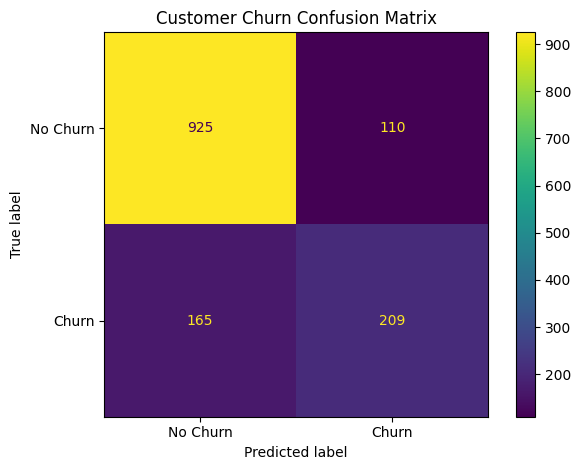

Confusion matrix saved as confusion_matrix.png


In [25]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

display.plot(values_format="d")

plt.title("Customer Churn Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved as confusion_matrix.png")

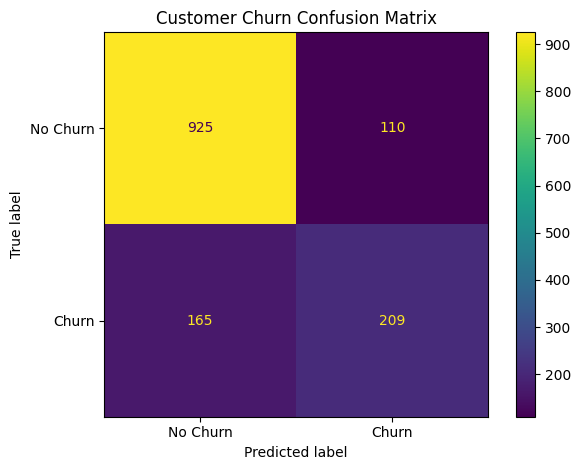

Confusion matrix saved as confusion_matrix.png


In [26]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

display.plot(values_format="d")

plt.title("Customer Churn Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved as confusion_matrix.png")

In [27]:
import joblib

pipeline_filename = "customer_churn_pipeline.joblib"

joblib.dump(
    best_pipeline,
    pipeline_filename
)

print("Complete ML pipeline exported successfully.")
print("Saved file:", pipeline_filename)

Complete ML pipeline exported successfully.
Saved file: customer_churn_pipeline.joblib


In [28]:
loaded_pipeline = joblib.load(
    "customer_churn_pipeline.joblib"
)

print("Saved pipeline loaded successfully.")
print("Loaded classifier:")
print(loaded_pipeline.named_steps["classifier"])

Saved pipeline loaded successfully.
Loaded classifier:
LogisticRegression(C=10.0, max_iter=2000, random_state=42, solver='liblinear')


In [29]:
loaded_predictions = loaded_pipeline.predict(X_test)

same_predictions = (
    loaded_predictions == y_pred
).all()

print(
    "Reloaded pipeline produces the same predictions:",
    same_predictions
)

Reloaded pipeline produces the same predictions: True


In [30]:
new_customer = pd.DataFrame([
    {
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "No",
        "tenure": 5,
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "Fiber optic",
        "OnlineSecurity": "No",
        "OnlineBackup": "No",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "Yes",
        "Contract": "Month-to-month",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check",
        "MonthlyCharges": 89.50,
        "TotalCharges": 447.50
    }
])

new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.5,447.5


In [31]:
new_prediction = loaded_pipeline.predict(
    new_customer
)[0]

new_probability = loaded_pipeline.predict_proba(
    new_customer
)[0][1]

print("NEW CUSTOMER PREDICTION")
print("-" * 35)

if new_prediction == 1:
    print("Prediction: Customer is likely to churn.")
else:
    print("Prediction: Customer is unlikely to churn.")

print(
    f"Churn probability: "
    f"{new_probability * 100:.2f}%"
)

NEW CUSTOMER PREDICTION
-----------------------------------
Prediction: Customer is likely to churn.
Churn probability: 77.40%


In [32]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

selected_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "params"
]

model_comparison = grid_results[
    selected_columns
].sort_values(
    by="rank_test_score"
)

model_comparison.head(10)

,rank_test_score,mean_test_score,std_test_score,params
4,1,0.845882,0.013804,{'classifier': LogisticRegression(max_iter=200...
5,2,0.845855,0.013775,{'classifier': LogisticRegression(max_iter=200...
2,3,0.845589,0.013857,{'classifier': LogisticRegression(max_iter=200...
3,4,0.845562,0.013874,{'classifier': LogisticRegression(max_iter=200...
1,5,0.844855,0.014122,{'classifier': LogisticRegression(max_iter=200...
0,6,0.844780,0.014096,{'classifier': LogisticRegression(max_iter=200...
13,7,0.843743,0.011656,{'classifier': RandomForestClassifier(n_jobs=-...
12,8,0.843487,0.011001,{'classifier': RandomForestClassifier(n_jobs=-...
11,9,0.842283,0.013036,{'classifier': RandomForestClassifier(n_jobs=-...
10,10,0.841966,0.011557,{'classifier': RandomForestClassifier(n_jobs=-...


In [33]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("GridSearchCV results saved as model_comparison.csv")

GridSearchCV results saved as model_comparison.csv


In [34]:
import os
import zipfile

output_files = [
    "customer_churn_pipeline.joblib",
    "evaluation_results.csv",
    "model_comparison.csv",
    "confusion_matrix.png"
]

zip_filename = "customer_churn_project_outputs.zip"

with zipfile.ZipFile(zip_filename, "w") as zip_file:
    for filename in output_files:
        if os.path.exists(filename):
            zip_file.write(filename)
            print("Added:", filename)

print("\nZIP file created:", zip_filename)

Added: customer_churn_pipeline.joblib
Added: model_comparison.csv
Added: confusion_matrix.png

ZIP file created: customer_churn_project_outputs.zip


In [35]:
from google.colab import files

files.download(
    "customer_churn_project_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>